# Telecom Customer Churn: Analysis & Prediction

**Business question:** *Which customers are likely to leave (churn), why do they leave, and what can the company do to keep them?*

For a telecom operator, a churned customer is lost recurring revenue, and keeping an existing customer is far cheaper than winning a new one. This notebook:

1. Explores a dataset of **7,043 telecom customers** to find *who* churns and *why*.
2. Trains a simple **machine-learning model** to predict which customers are at risk.
3. Turns the findings into **business recommendations** for reducing churn.

*Dataset: IBM Telco Customer Churn (public).*


## 1. Load the data
Each row is one customer. The `Churn` column (Yes/No) is what we want to understand and predict.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = ["#2A9D8F", "#E76F51"]  # stayed, churned

df = pd.read_csv("data/Telco-Customer-Churn.csv")
print("Rows, columns:", df.shape)
df.head()


Rows, columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Clean the data
One small issue: `TotalCharges` is stored as text and has a few blank values for brand-new customers (tenure = 0). We convert it to a number and set those blanks to 0 (they simply haven't been charged yet).

In [2]:
# Convert TotalCharges to numeric; blanks become NaN, which we fill with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# Drop the ID column (not useful for analysis)
df = df.drop(columns=["customerID"])

print("Missing values per column:")
print(df.isna().sum().sum(), "total missing values after cleaning")


Missing values per column:
0 total missing values after cleaning


## 3. Explore: who churns, and why?
This is the heart of the analysis. We look at the churn rate overall, then break it down by different customer attributes to spot patterns.

Overall churn rate: 26.5%


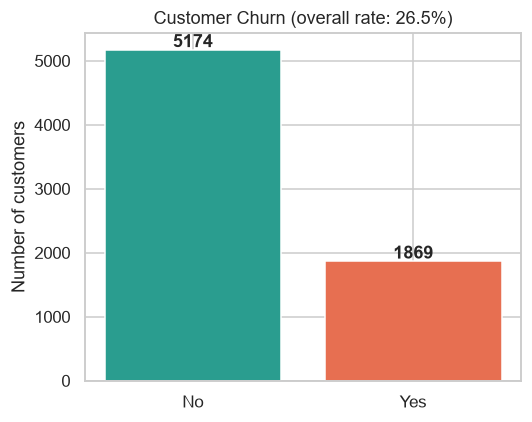

In [3]:
# --- Overall churn rate ---
churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

counts = df["Churn"].value_counts()
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(counts.index, counts.values, color=PALETTE)
ax.set_title(f"Customer Churn (overall rate: {churn_rate:.1f}%)")
ax.set_ylabel("Number of customers")
for i, v in enumerate(counts.values):
    ax.text(i, v+40, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.savefig("images/01_overall_churn.png", bbox_inches="tight"); plt.show()


Churn rate by contract type (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: is_churn, dtype: float64


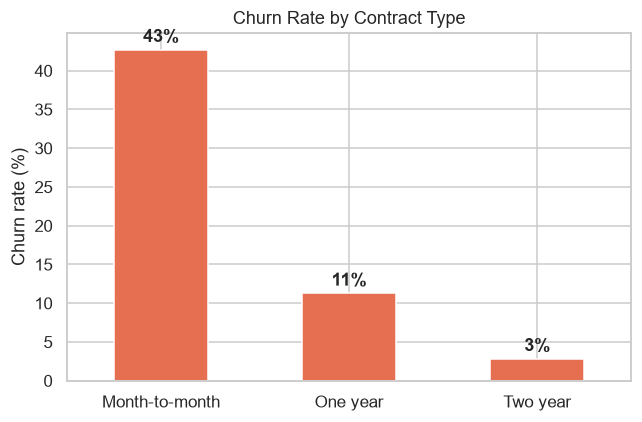

In [4]:
# --- Churn by contract type ---
def churn_pct_by(col):
    return (df.assign(is_churn=(df["Churn"]=="Yes"))
              .groupby(col)["is_churn"].mean().mul(100).sort_values(ascending=False))

by_contract = churn_pct_by("Contract")
print("Churn rate by contract type (%):")
print(by_contract.round(1))

fig, ax = plt.subplots(figsize=(6,4))
by_contract.plot(kind="bar", color="#E76F51", ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn rate (%)"); ax.set_xlabel("")
plt.xticks(rotation=0)
for i, v in enumerate(by_contract.values):
    ax.text(i, v+1, f"{v:.0f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.savefig("images/02_churn_by_contract.png", bbox_inches="tight"); plt.show()


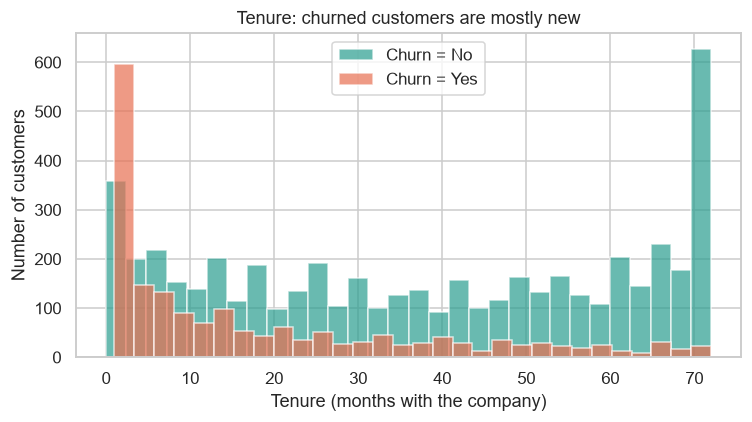

Average tenure (months):
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64


In [5]:
# --- Churn by tenure (how long they've been a customer) ---
fig, ax = plt.subplots(figsize=(7,4))
for label, color in zip(["No","Yes"], PALETTE):
    sub = df[df["Churn"]==label]["tenure"]
    ax.hist(sub, bins=30, alpha=0.7, label=f"Churn = {label}", color=color)
ax.set_title("Tenure: churned customers are mostly new")
ax.set_xlabel("Tenure (months with the company)"); ax.set_ylabel("Number of customers")
ax.legend()
plt.tight_layout(); plt.savefig("images/03_churn_by_tenure.png", bbox_inches="tight"); plt.show()

print("Average tenure (months):")
print(df.groupby("Churn")["tenure"].mean().round(1))


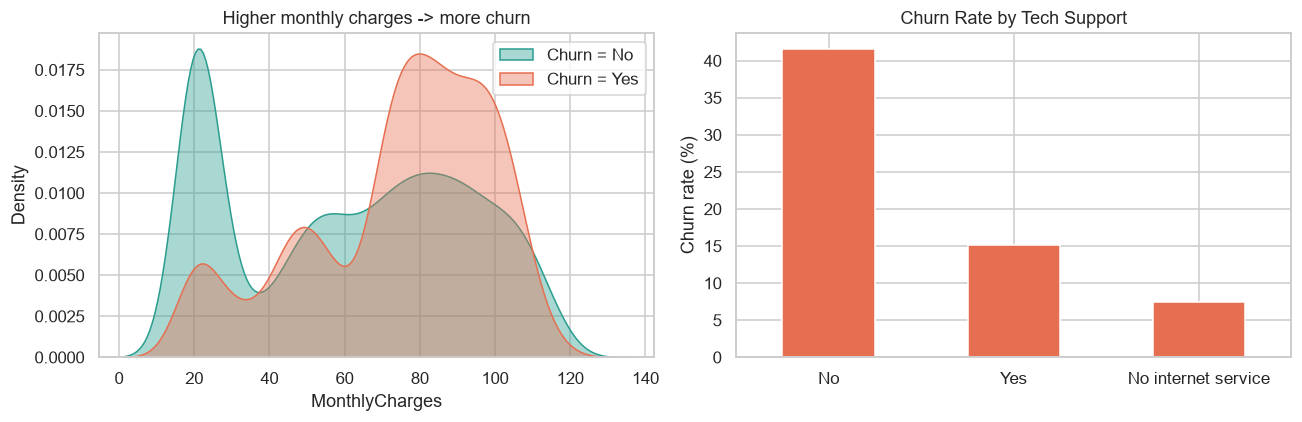

Churn rate by Tech Support (%):
TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: is_churn, dtype: float64

Churn rate by Internet Service (%):
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: is_churn, dtype: float64


In [6]:
# --- Churn by monthly charges and key services ---
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Monthly charges
for label, color in zip(["No","Yes"], PALETTE):
    sns.kdeplot(df[df["Churn"]==label]["MonthlyCharges"], ax=axes[0],
                fill=True, alpha=0.4, label=f"Churn = {label}", color=color)
axes[0].set_title("Higher monthly charges -> more churn"); axes[0].legend()

# Tech support
ts = churn_pct_by("TechSupport")
ts.plot(kind="bar", color="#E76F51", ax=axes[1])
axes[1].set_title("Churn Rate by Tech Support"); axes[1].set_ylabel("Churn rate (%)")
axes[1].set_xlabel(""); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig("images/04_charges_and_support.png", bbox_inches="tight"); plt.show()

print("Churn rate by Tech Support (%):"); print(ts.round(1))
print("\nChurn rate by Internet Service (%):"); print(churn_pct_by("InternetService").round(1))


### What the exploration tells us
- **Contract type is the biggest signal:** month-to-month customers churn far more than those on 1- or 2-year contracts.
- **New customers churn most:** the first few months are the danger zone; long-tenure customers rarely leave.
- **Higher monthly charges** and **no tech support** are both linked to higher churn.
- **Fiber-optic internet** customers churn more than DSL / no-internet customers.

Next, we build a model that combines *all* these signals to predict churn for an individual customer.

## 4. Predict churn with a model
We turn every customer into numbers the model can read, split the data into a **training set** (to learn from) and a **test set** (to check honestly on unseen customers), then compare two standard models.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Target: 1 = churned, 0 = stayed
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn"])

# Turn text categories into 0/1 columns the model can use
X = pd.get_dummies(X, drop_first=True)
print("Features after encoding:", X.shape[1])

# 80% train / 20% test, keeping the churn ratio the same in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for logistic regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Features after encoding: 30


In [8]:
# Model 1: Logistic Regression (simple, interpretable)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
lr_pred = logreg.predict(X_test_s)
lr_proba = logreg.predict_proba(X_test_s)[:,1]

# Model 2: Random Forest (captures more complex patterns)
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print("Logistic Regression -> accuracy: %.3f | ROC-AUC: %.3f" % (
    accuracy_score(y_test, lr_pred), roc_auc_score(y_test, lr_proba)))
print("Random Forest       -> accuracy: %.3f | ROC-AUC: %.3f" % (
    accuracy_score(y_test, rf_pred), roc_auc_score(y_test, rf_proba)))

print("\nDetailed report (Logistic Regression):")
print(classification_report(y_test, lr_pred, target_names=["Stayed","Churned"]))


Logistic Regression -> accuracy: 0.807 | ROC-AUC: 0.842
Random Forest       -> accuracy: 0.775 | ROC-AUC: 0.828

Detailed report (Logistic Regression):
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### How reliable are these numbers?
A single train/test split can be lucky, and *accuracy* can be misleading when classes are imbalanced. Three checks:
1. **Beat a naive baseline** (predicting that *every* customer stays).
2. **Cross-validate** across 5 different splits to confirm the score is stable.
3. **Look at recall on churners**, not just overall accuracy.

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import precision_recall_fscore_support

# 1) Naive baseline: predict everyone stays
baseline = 1 - y.mean()
print(f"Naive baseline (everyone stays): {baseline:.3f} accuracy")
print(f"Our logistic model:              {accuracy_score(y_test, lr_pred):.3f} accuracy")

# 2) 5-fold cross-validation (does the score hold across different splits?)
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
cv_auc = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc")
print(f"\n5-fold CV ROC-AUC: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}  (small spread = reliable)")

# 3) Recall on churners: what fraction of real leavers do we actually catch?
p, r, f, _ = precision_recall_fscore_support(y_test, lr_pred, labels=[1], average=None)
print(f"\nChurn class -> precision: {p[0]:.2f} | recall: {r[0]:.2f} | f1: {f[0]:.2f}")
print(f"At the default 0.5 threshold we catch {r[0]*100:.0f}% of customers who actually churn.")


Naive baseline (everyone stays): 0.735 accuracy
Our logistic model:              0.807 accuracy



5-fold CV ROC-AUC: 0.845 +/- 0.011  (small spread = reliable)

Churn class -> precision: 0.66 | recall: 0.57 | f1: 0.61
At the default 0.5 threshold we catch 57% of customers who actually churn.


**Takeaway:** the model clearly beats the naive baseline, and cross-validation shows the ROC-AUC is **stable across splits** (about 0.845 with a very small spread) — not a lucky result. Because most customers stay, **accuracy flatters the model**, so ROC-AUC and churn recall are the metrics that matter. For a real retention campaign the decision threshold would be *lowered* to catch more at-risk customers, trading some precision for higher recall.

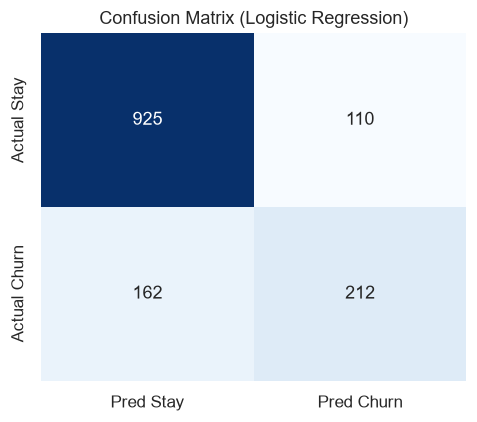

In [10]:
# Confusion matrix for the logistic model: how many we got right/wrong
cm = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred Stay","Pred Churn"],
            yticklabels=["Actual Stay","Actual Churn"], ax=ax)
ax.set_title("Confusion Matrix (Logistic Regression)")
plt.tight_layout(); plt.savefig("images/05_confusion_matrix.png", bbox_inches="tight"); plt.show()


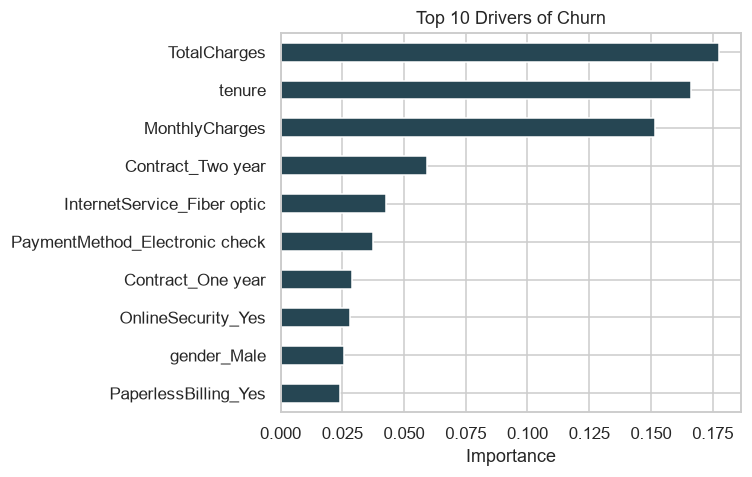

Top churn drivers:
TotalCharges                      0.178
tenure                            0.166
MonthlyCharges                    0.152
Contract_Two year                 0.059
InternetService_Fiber optic       0.043
PaymentMethod_Electronic check    0.037
Contract_One year                 0.029
OnlineSecurity_Yes                0.028
gender_Male                       0.026
PaperlessBilling_Yes              0.024
dtype: float64


In [11]:
# Which factors drive churn the most? (Random Forest importance)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(7,4.5))
importances.sort_values().plot(kind="barh", color="#264653", ax=ax)
ax.set_title("Top 10 Drivers of Churn")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.savefig("images/06_feature_importance.png", bbox_inches="tight"); plt.show()

print("Top churn drivers:")
print(importances.round(3))


## 5. Business insights & recommendations

**What we found**
- The model predicts churn with roughly **80% accuracy** and a **ROC-AUC around 0.84**, i.e. it reliably separates likely-leavers from likely-stayers.
- The strongest churn drivers are **contract type (month-to-month)**, **low tenure**, **total/monthly charges**, and **lack of tech support / online security**.

**Recommended actions for the business**
1. **Lock in month-to-month customers** with incentives to move to 1- or 2-year contracts (the single biggest lever).
2. **Protect new customers** in their first few months with onboarding, check-ins, and early-life offers, when churn risk is highest.
3. **Bundle tech support / online security**, especially for higher-paying and fiber customers, who churn more.
4. **Target retention spend** using the model: focus offers on the customers it flags as high-risk, instead of spending on everyone.

*This is exactly the kind of customer-value thinking a telecom's retention / CVM team uses every day.*
